# Part 1 (ETL)

- Data description
- Extract some test portion of the data
- Select the most relevant columns and load a larger portion of data
- Adjust the values and rename the columns where necessary
- Store the processed data

# ___ ___ ___

### This project uses publicly available Home Mortgage Disclosure Act (HMDA) data provided by the Consumer Financial Protection Bureau (CFPB) through its official HMDA data portal.

### https://www.consumerfinance.gov/data-research/hmda/historic-data/

### https://www.consumerfinance.gov/data-research/hmda/historic-data/?geo=nationwide&records=all-records&field_descriptions=labels

### The data we are analyzing is the one given for the year 2014.

### As the initial data takes lots of storage space, we proceed as follows:

- Load a piece of data and sort out the most important columns
- Load a larger piece of data only with the filtered columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for dashboards
from dash import Dash, html, dcc, Input, Output
import plotly.io as pio
import plotly.express as px
import dash_bootstrap_components as dbc
from IPython.display import IFrame
from IPython.display import FileLink

#for forecasting and feature selection
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, VarianceThreshold
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split
from sklearn.metrics import (roc_auc_score,average_precision_score,log_loss,accuracy_score,
                             precision_score,recall_score,f1_score)
from sklearn.dummy import DummyClassifier

#models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

C:\WinPython\WPy64-31050\python-3.10.5.amd64\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
N_rows=600000
chunk_size=100000

df0=pd.read_csv('hmda_2014_nationwide_all-records_labels.csv',nrows=N_rows,chunksize=chunk_size)
df0=pd.concat(df0,ignore_index=True)

C:\Users\ibrag\AppData\Local\Temp\ipykernel_84\2989757849.py:5: DtypeWarning: Columns (34,36,38,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df0=pd.concat(df0,ignore_index=True)
C:\Users\ibrag\AppData\Local\Temp\ipykernel_84\2989757849.py:5: DtypeWarning: Columns (34,36,38,44,46,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df0=pd.concat(df0,ignore_index=True)
C:\Users\ibrag\AppData\Local\Temp\ipykernel_84\2989757849.py:5: DtypeWarning: Columns (34,36,38,42,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df0=pd.concat(df0,ignore_index=True)
C:\Users\ibrag\AppData\Local\Temp\ipykernel_84\2989757849.py:5: DtypeWarning: Columns (34,36,38,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df0=pd.concat(df0,ignore_index=True)
C:\Users\ibrag\AppData\Local\Temp\ipykernel_84\2989757849.py:5: DtypeWarning: Columns (36,38,44,46) have mixed types. Specify dtype option 

### Sort out the columns with too many null values

In [3]:
df_check=pd.DataFrame( { 'Column':df0.columns,
                       'Is null':df0.isnull().sum().values} )

N_nulls_max=100000

columns=[column for column in df0.columns if
         df_check.loc[df_check['Column']==column,'Is null'].iloc[0]<N_nulls_max]

df=df0[columns]

### Select only the most relevant features

In [4]:
df.columns

Index(['as_of_year', 'respondent_id', 'agency_name', 'agency_abbr',
       'agency_code', 'loan_type_name', 'loan_type', 'property_type_name',
       'property_type', 'loan_purpose_name', 'loan_purpose',
       'owner_occupancy_name', 'owner_occupancy', 'loan_amount_000s',
       'preapproval_name', 'preapproval', 'action_taken_name', 'action_taken',
       'msamd_name', 'msamd', 'state_name', 'state_abbr', 'state_code',
       'county_name', 'county_code', 'census_tract_number',
       'applicant_ethnicity_name', 'applicant_ethnicity',
       'co_applicant_ethnicity_name', 'co_applicant_ethnicity',
       'applicant_race_name_1', 'applicant_race_1', 'co_applicant_race_name_1',
       'co_applicant_race_1', 'applicant_sex_name', 'applicant_sex',
       'co_applicant_sex_name', 'co_applicant_sex', 'applicant_income_000s',
       'purchaser_type_name', 'purchaser_type', 'hoepa_status_name',
       'hoepa_status', 'lien_status_name', 'lien_status', 'sequence_number',
       'population', 

In [5]:
filtered_columns=[
    #loan/application characteristics
    'loan_type', 'loan_type_name',
    'property_type', 'property_type_name',
    'loan_purpose', 'loan_purpose_name',
    'owner_occupancy', 'owner_occupancy_name', ### <--- whether the borrower planned to live in the property
    'loan_amount_000s',
    'applicant_income_000s',
    'lien_status', 'lien_status_name', ### <--- lien is a legal claim giving the lender the right to seize and 
                                       ### sell the property if the dept is not paid

    #applicant demographics
    'applicant_ethnicity', 'applicant_ethnicity_name',
    'applicant_race_1', 'applicant_race_name_1',
    'applicant_sex', 'applicant_sex_name',

    #co-applicant demographics
    'co_applicant_ethnicity', 'co_applicant_ethnicity_name',
    'co_applicant_race_1', 'co_applicant_race_name_1',
    'co_applicant_sex', 'co_applicant_sex_name',

    #geography
    'state_code', 'state_name', 'state_abbr',
    'county_code', 'county_name',
    'census_tract_number', ### <--- census tract is a small geographic area code
    'msamd', 'msamd_name', ### <--- describe the metropolitan area where the object is located

    #neighborhood / census tract characteristics
    'population', ### <--- number of people in the census tract
    'minority_population',
    'hud_median_family_income', ### <--- estimate for the median family income in the area
    'tract_to_msamd_income', ### <--- how census tract income compares to the broader area income
    'number_of_owner_occupied_units', ### <--- number of housing units occupied by owners, not renters
    'number_of_1_to_4_family_units', ### <--- number of small residential buildings
    
    'action_taken', 'action_taken_name' ### <--- result of the application
]

### Re-upload the data frame with the most relevant columns

In [6]:
N_rows=2000000
chunk_size=100000

df0=pd.read_csv('hmda_2014_nationwide_all-records_labels.csv',usecols=filtered_columns,nrows=N_rows,chunksize=chunk_size)
df=pd.concat(df0,ignore_index=True)

### Adjust values and column names

In [7]:
#remove the rows with incomplete/irrelevant information
filtered_columns_cat=[
    column for column in filtered_columns
    if ((column.endswith('name')==True)
    or (column.endswith('name_1')))
]

mask_tags=[
    'Information not provided by applicant in mail, Internet, or telephone application',
    'Not applicable'
]

mask=df[filtered_columns_cat].isin(mask_tags)

df[filtered_columns_cat]=df[filtered_columns_cat][~mask]

df=df.dropna().reset_index().drop(columns='index')

#adjust some columns representing values in thousands to normal
for col in list(df.columns):
    if col.endswith('_000s'):
        df[col]=df[col]*1000
        df=df.rename(columns={f'{col}':col[:-5]})

#refresh column names after renaming
filtered_columns=list(df.columns)

filtered_columns_cat=[
    column for column in filtered_columns
    if ((column.endswith('name')==True)
    or (column.endswith('name_1')))
]

filtered_columns_other=list(set(filtered_columns)-set(filtered_columns_cat))

# create numerical columns
x=[
    x for x in filtered_columns_other 
     if ((x+'_name') not in filtered_columns_cat)
     and ((x[:-1]+'name_1') not in filtered_columns_cat)
  ]
filtered_columns_num=[col for col in x if df[col].dtype!='O']
del x

#df represented by the categorical+numerical columns
x=filtered_columns_cat
y=filtered_columns_num
df=df[x+y]
del x,y

#group the outcomes of a loan into the positive and the negative ones
df['action_taken_name_original']=df['action_taken_name']

df['action_taken_name']=np.where(df['action_taken_name'] == 'Loan originated',
                                   'Loan originated',
                                   'Loan not originated')

#add loan success column
df['loan_success']=(df['action_taken_name']=='Loan originated').astype(int)

### As there are some numeric columns of high importance, we would like to bin those in order to simplify the representation

In [8]:
columns_to_bin=['tract_to_msamd_income',
                'minority_population',
                'number_of_owner_occupied_units',
                'applicant_income',
                'number_of_1_to_4_family_units',
                'loan_amount',
                'population',
                'hud_median_family_income']

for column in columns_to_bin:

    bins=[int(df[column].min().round(0)),
          int(df[column].quantile(0.25).round(0)),
          int(df[column].quantile(0.75).round(0)),
          int(df[column].max().round(0))]

    labels=[f'Low ({bins[0]}-{bins[1]})',f'Medium ({bins[1]}-{bins[2]})',f'High ({bins[2]}-{bins[3]})']
    #labels=['Low','Medium','High']

    df[column+'_bin']=pd.cut(df[column],bins=bins,labels=labels,include_lowest=True)

### Now we have got two types of columns:

- filtered_columns_cat - categorical columns
- filtered_columns_num - numerical columns

### and our data frame is the combination of those columns

In [9]:
df.describe()

,number_of_1_to_4_family_units,census_tract_number,applicant_income,loan_amount,minority_population,state_code,county_code,number_of_owner_occupied_units,population,tract_to_msamd_income,hud_median_family_income,loan_success
count,1.174369e+06,1.174369e+06,1.174369e+06,1.174369e+06,1.174369e+06,1.174369e+06,1.174369e+06,1.174369e+06,1.174369e+06,1.174369e+06,1.174369e+06,1.174369e+06
mean,1.831263e+03,1.611287e+03,1.049338e+05,2.027797e+05,3.247625e+01,2.821645e+01,8.656943e+01,1.418951e+03,5.405082e+03,1.160780e+02,6.835317e+04,6.396252e-01
std,8.696272e+02,2.657658e+03,1.594788e+05,2.114425e+05,2.697603e+01,1.792116e+01,1.026417e+02,7.165040e+02,2.562031e+03,4.295727e+01,1.402544e+04,4.801094e-01
min,1.000000e+00,1.000000e+00,1.000000e+03,1.000000e+03,3.400000e-01,1.000000e+00,1.000000e+00,3.000000e+00,3.100000e+01,6.350000e+00,1.750000e+04,0.000000e+00
25%,1.268000e+03,8.370000e+01,4.800000e+04,9.600000e+04,1.125000e+01,1.200000e+01,2.000000e+01,9.370000e+02,3.755000e+03,8.859000e+01,6.070000e+04,0.000000e+00
50%,1.717000e+03,2.610100e+02,7.500000e+04,1.580000e+05,2.310000e+01,2.600000e+01,6.500000e+01,1.330000e+03,5.011000e+03,1.099700e+02,6.840000e+04,1.000000e+00
75%,2.257000e+03,1.608010e+03,1.190000e+05,2.540000e+05,4.682000e+01,4.500000e+01,1.110000e+02,1.790000e+03,6.477000e+03,1.360600e+02,7.490000e+04,1.000000e+00
max,1.322700e+04,9.856000e+03,9.999000e+06,2.350000e+07,1.000000e+02,7.200000e+01,8.400000e+02,8.526000e+03,3.320100e+04,4.754400e+02,1.113000e+05,1.000000e+00


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174369 entries, 0 to 1174368
Data columns (total 36 columns):
 #   Column                              Non-Null Count    Dtype   
---  ------                              --------------    -----   
 0   loan_type_name                      1174369 non-null  object  
 1   property_type_name                  1174369 non-null  object  
 2   loan_purpose_name                   1174369 non-null  object  
 3   owner_occupancy_name                1174369 non-null  object  
 4   action_taken_name                   1174369 non-null  object  
 5   msamd_name                          1174369 non-null  object  
 6   state_name                          1174369 non-null  object  
 7   county_name                         1174369 non-null  object  
 8   applicant_ethnicity_name            1174369 non-null  object  
 9   co_applicant_ethnicity_name         1174369 non-null  object  
 10  applicant_race_name_1               1174369 non-null  object  
 11

In [11]:
df.shape

(1174369, 36)

In [12]:
# df.to_csv('hmda_2014 data processed.csv',index=False)

# df=pd.read_csv('hmda_2014 data processed.csv')

# ___ ___ ___

# Part 2 (EDA)

- General analysis (general stats, class imbalance, numeric distribution, pivot heatmaps, state level success rate analysis)
- Dashboard
- Demographic disparity analysis
- Correlation analysis

# ___ ___ ___

### General stats

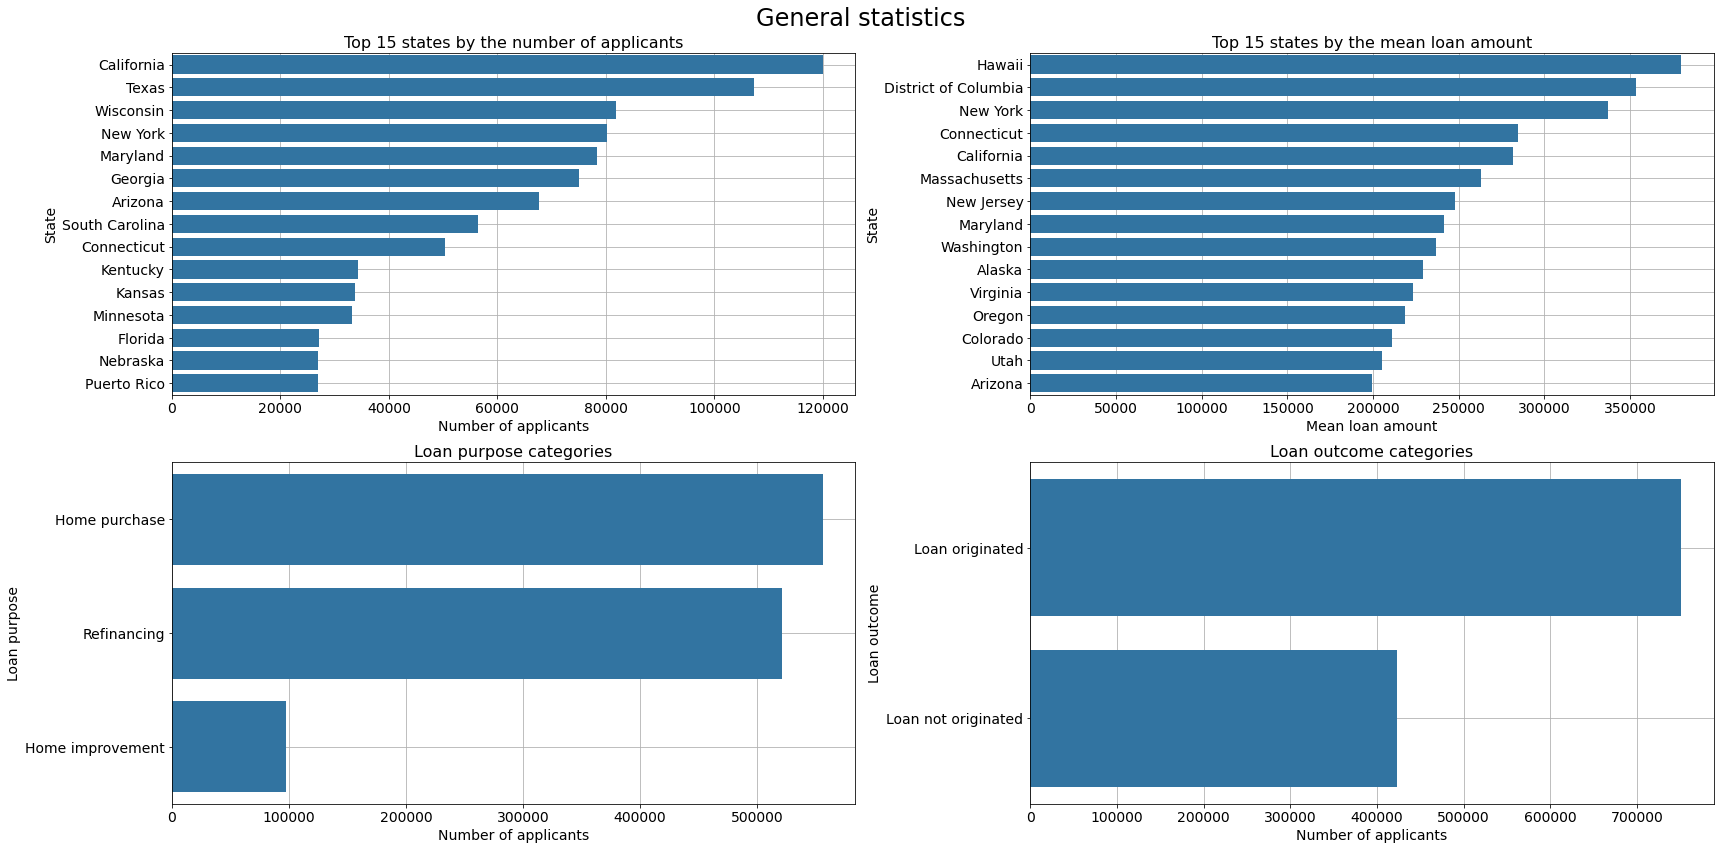

In [13]:
fig,axes=plt.subplots(2,2,figsize=(24,12))
plt.style.use('ggplot')

z=df['state_name'].value_counts().head(15)
sns.barplot(x=z.values,y=z.index,ax=axes[0,0])
axes[0,0].set_ylabel('State',fontsize=14)
axes[0,0].set_title('Top 15 states by the number of applicants',fontsize=16)

z=(df.groupby('state_name')['loan_amount']
   .mean()
   .sort_values(ascending=False).head(15))
sns.barplot(x=z.values,y=z.index,ax=axes[0,1])
axes[0,1].set_ylabel('State',fontsize=14)
axes[0,1].set_title('Top 15 states by the mean loan amount',fontsize=16)

z=df['loan_purpose_name'].value_counts().head(15)
sns.barplot(x=z.values,y=z.index,ax=axes[1,0])
axes[1,0].set_ylabel('Loan purpose',fontsize=14)
axes[1,0].set_title('Loan purpose categories',fontsize=16)

z=df['action_taken_name'].value_counts().head(15)
sns.barplot(x=z.values,y=z.index,ax=axes[1,1])
axes[1,1].set_ylabel('Loan outcome',fontsize=14)
axes[1,1].set_title('Loan outcome categories',fontsize=16)

for i in range(2):
    for j in range(2):
        axes[i,j].tick_params(axis='x',labelsize=14)
        axes[i,j].tick_params(axis='y',labelsize=14)
        if i==0 and j==1:
            axes[i,j].set_xlabel('Mean loan amount',fontsize=14)
        else:
            axes[i,j].set_xlabel('Number of applicants',fontsize=14)
        axes[i,j].set_axisbelow(True)
        axes[i,j].grid(True)

fig.suptitle('General statistics',fontsize=24)
plt.tight_layout()

#uncomment for saving
#plt.savefig("GENERAL STATS.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### The dataset is concentrated in several high-volume states, especially California and Texas. Home purchase and refinancing are the dominant loan purposes, and originated loans represent the majority of outcomes. Mean loan amounts vary substantially across states.

### Target distribution and class imbalance

In [14]:
(df['loan_success'].value_counts(normalize=True)*100).round(2)

loan_success
1    63.96
0    36.04
Name: proportion, dtype: float64

In [15]:
print('Imbalance ratio is ',
      ((df['loan_success'].value_counts(normalize=True)*100).iloc[0]
      /(df['loan_success'].value_counts(normalize=True)*100).iloc[1]).round(2),': 1')

Imbalance ratio is  1.77 : 1


### The target is mildly imbalanced: originated loans make up 63.96% of the data, while non-originated loans make up 36.04%.

### Numeric distribution by loan success

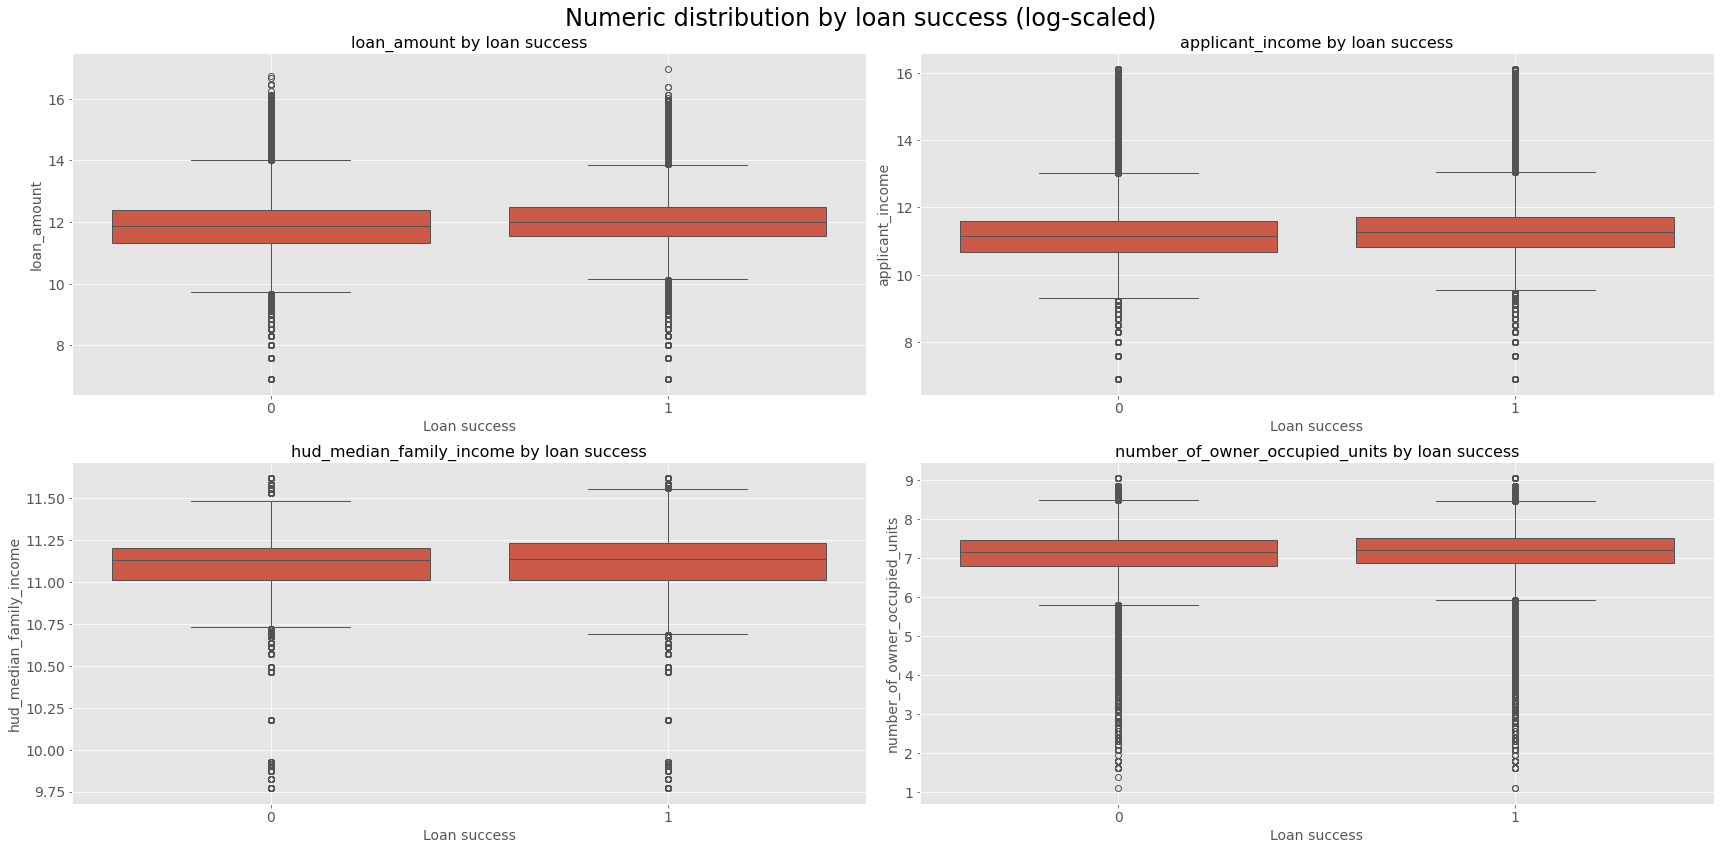

In [16]:
x=['loan_amount','applicant_income','hud_median_family_income','number_of_owner_occupied_units']

fig,axes=plt.subplots(2,2,figsize=(24,12))
axes=axes.ravel()

for ax,col in zip(axes,x):
    sns.boxplot(data=df,x='loan_success',y=np.log(df[col]),ax=ax)
    ax.set_title(f'{col} by loan success',fontsize=16)
    ax.set_xlabel('Loan success',fontsize=14)
    ax.set_ylabel(col, fontsize=14)
    ax.tick_params(axis='x',labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.grid(True)
    ax.set_axisbelow(True)

fig.suptitle('Numeric distribution by loan success (log-scaled)',fontsize=24)
plt.tight_layout()

#uncomment for saving
#plt.savefig("NUMERIC DISTRIBUTION BY LOAN SUCCESS.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

del x

### Successful loans show slightly higher loan amounts, applicant income, and area median family income. The distributions overlap heavily, so these numeric variables alone do not clearly separate successful from non-successful applications.

### Loan amount bin / applicant income amount bin heatmap

C:\Users\ibrag\AppData\Local\Temp\ipykernel_84\666191639.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


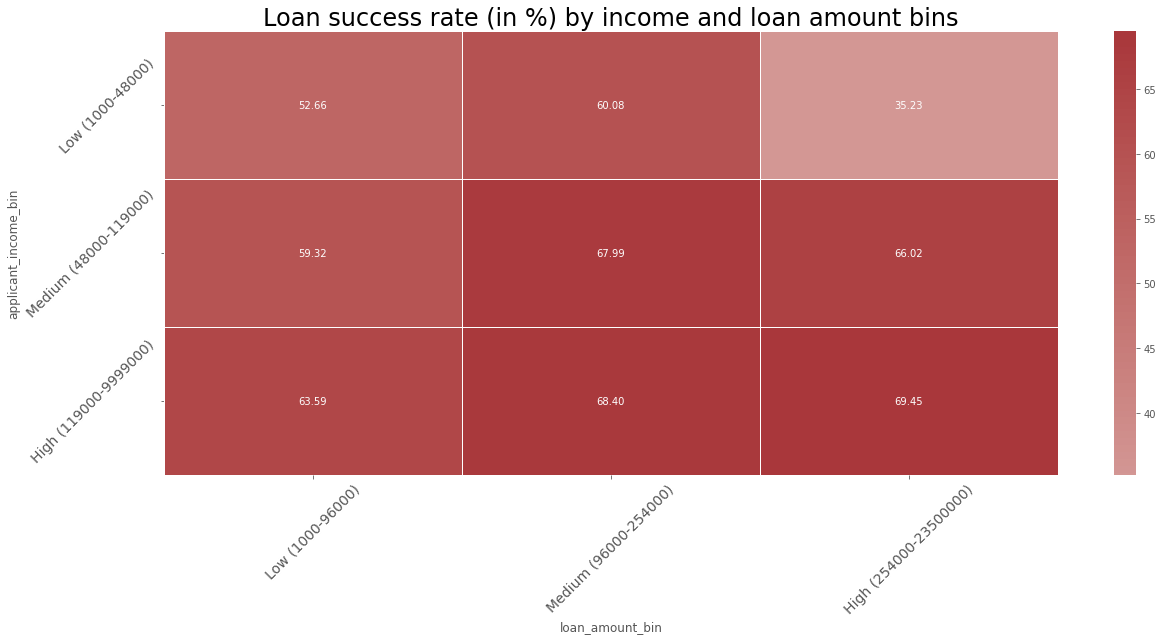

In [17]:
pivot=(
    df.pivot_table(
        index='applicant_income_bin',
        columns='loan_amount_bin',
        values='loan_success',
        aggfunc='mean'
    )*100
).round(2)

fig,axes=plt.subplots(1,1,figsize=(18,9))
plt.style.use('ggplot')

sns.heatmap(pivot,annot=True,cmap='vlag',center=0,linewidth=1,fmt=".2f",ax=axes)
axes.set_title('Loan success rate (in %) by income and loan amount bins',fontsize=24)

axes.tick_params(axis='x',labelsize=14,rotation=45)
axes.tick_params(axis='y',labelsize=14,rotation=45)
axes.set_axisbelow(True)
axes.grid(True)

plt.tight_layout()

#uncomment for saving
#plt.savefig("PIVOTED LOAN,INCOME HEATMAP .png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### Loan success rates are highest for high-income applicants, especially when loan amounts are medium or high. Low-income applicants show noticeably lower success rates, particularly for high loan amounts. Overall, income appears to be more strongly associated with loan success than loan amount alone.

### State-level success rate analysis

In [18]:
df_by_state=(df
             .groupby('state_name')['loan_success']
             .agg( **{
                 'total (#)':'size',
                 'success_rate_%': lambda x: x.mean()*100
                         } )
             .reset_index()
            )
             
#sort out the bottom 25% states by the total number of applications
df_by_state=df_by_state[df_by_state['total (#)']>=df_by_state['total (#)'].quantile(0.25)]

In [19]:
df_by_state[['total (#)','success_rate_%']].corr()

,total (#),success_rate_%
total (#),1.000000,-0.335878
success_rate_%,-0.335878,1.000000


### After removing the lowest-volume states, total application volume has a moderate negative correlation with loan success rate.

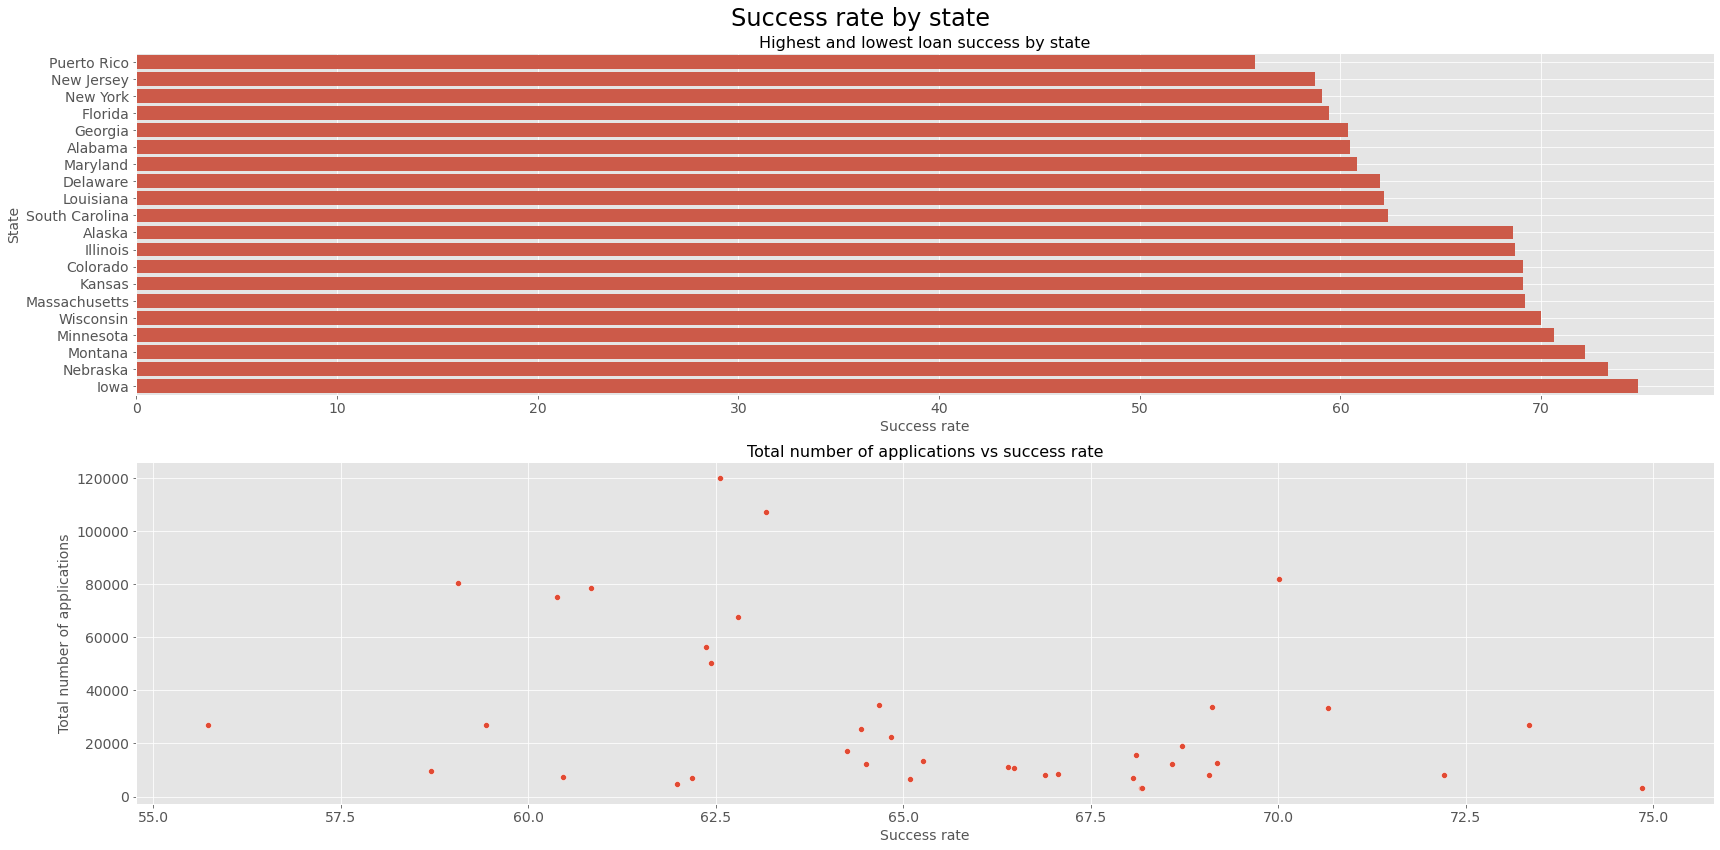

In [20]:
fig,axes=plt.subplots(2,1,figsize=(24,12))
plt.style.use('ggplot')

plot_df = pd.concat([
    df_by_state.sort_values('success_rate_%').head(10),
    df_by_state.sort_values('success_rate_%').tail(10)
])

sns.barplot(data=plot_df,x='success_rate_%',y='state_name',ax=axes[0])
axes[0].set_ylabel('State',fontsize=14)
axes[0].set_title('Highest and lowest loan success by state',fontsize=16)


plot_df=df_by_state[['total (#)','success_rate_%']]
sns.scatterplot(data=plot_df,x='success_rate_%',y='total (#)',ax=axes[1])
axes[1].set_ylabel('Total number of applications',fontsize=14)
axes[1].set_title('Total number of applications vs success rate',fontsize=16)

for j in range(2):
    axes[j].tick_params(axis='x',labelsize=14)
    axes[j].tick_params(axis='y',labelsize=14)
    axes[j].set_xlabel('Success rate',fontsize=14)
    axes[j].set_axisbelow(True)
    axes[j].grid(True)

fig.suptitle('Success rate by state',fontsize=24)
plt.tight_layout()

#uncomment for saving
#plt.savefig("STATE LEVEL COMPARISON.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### Loan success rates vary noticeably across states, with Puerto Rico among the lowest and Iowa/Nebraska among the highest in this filtered sample. The scatterplot suggests a weak-to-moderate negative relationship between application volume and success rate, as seen before.

### Dashboard via Dash plotly

### Now we are interested in considering the proportion of successful applications across different characteristics. We'll use Dashboard for that purpose

In [21]:
df_stat=[]

selected_columns=[
                 col for col in df.columns if 
                 ( (df[col].dtype!='int64')
                  and (df[col].dtype!='float64')
                  and (col!='action_taken_name') )
]

for col in selected_columns:
    
    dff=(df
         .groupby(col)['loan_success']
         .agg(Total='size',Successful='sum')
         .reset_index()
         .rename(columns={col:'Subfeature',
                          'Total':'Total (#)',
                          'Successful':'Successful (#)'}))
    dff['Feature']=col
    dff['Successful (%)']=dff['Successful (#)']/dff['Total (#)'] * 100
    
    df_stat.append(dff)
    
df_stat=pd.concat(df_stat,ignore_index=True)

df_stat=df_stat[['Feature','Subfeature','Total (#)','Successful (#)','Successful (%)']]

C:\Users\ibrag\AppData\Local\Temp\ipykernel_84\1546224692.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col)['loan_success']
C:\Users\ibrag\AppData\Local\Temp\ipykernel_84\1546224692.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col)['loan_success']
C:\Users\ibrag\AppData\Local\Temp\ipykernel_84\1546224692.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col)['loan_success']
C

In [22]:
# df_stat.to_csv('df_stat.csv',index=False)

# df_stat=pd.read_csv('df_stat.csv')

In [23]:
pio.templates.default='ggplot2'

### ***All instructions on how to run the dashboard are given here:*** ###
### ***1. run the cell as code (change the format from Raw to Code)*** ###
### ***2. in the browser type in http://127.0.0.1:8051/*** ###
### ***3. access the dashboard in the new window*** ###

### Examples for figures from the dashboard can be found in the respective project folder

### Demographic disparity analysis

In [24]:
applicant_columns=['applicant_race_name_1','applicant_ethnicity_name','applicant_sex_name']
co_applicant_columns=['co_'+x for x in applicant_columns]

df_stat_disp=[]

for applicant_column,co_applicant_column in zip(applicant_columns,co_applicant_columns):

    dff=(
        df
        .groupby([applicant_column,co_applicant_column])['loan_success']
        .agg(
            **{
               'Total (#)':'size',
               'Successful (#)':'sum',
               'Successful (%)':lambda x: x.mean()*100
        }
        )
        .reset_index()
    )
    
    dff=dff.rename(columns={
    applicant_column:'Applicant',
    co_applicant_column:'Co-applicant'
                   })
    
    dff['Characteristic']=applicant_column
    
    dff['Applicant|Co-applicant']= (dff['Applicant'].astype(str) + '|\n' + dff['Co-applicant'].astype(str))
    
    dff=dff[['Characteristic','Applicant|Co-applicant','Applicant','Co-applicant','Total (#)','Successful (#)','Successful (%)']]
    
    df_stat_disp.append(dff)
    
df_stat_disp=pd.concat(df_stat_disp)

#filter out the statistically negligible (i.e. w/ low total(#)) rows
tolerance=0.01

df_stat_disp=df_stat_disp[df_stat_disp['Total (#)']>=tolerance*len(df)]

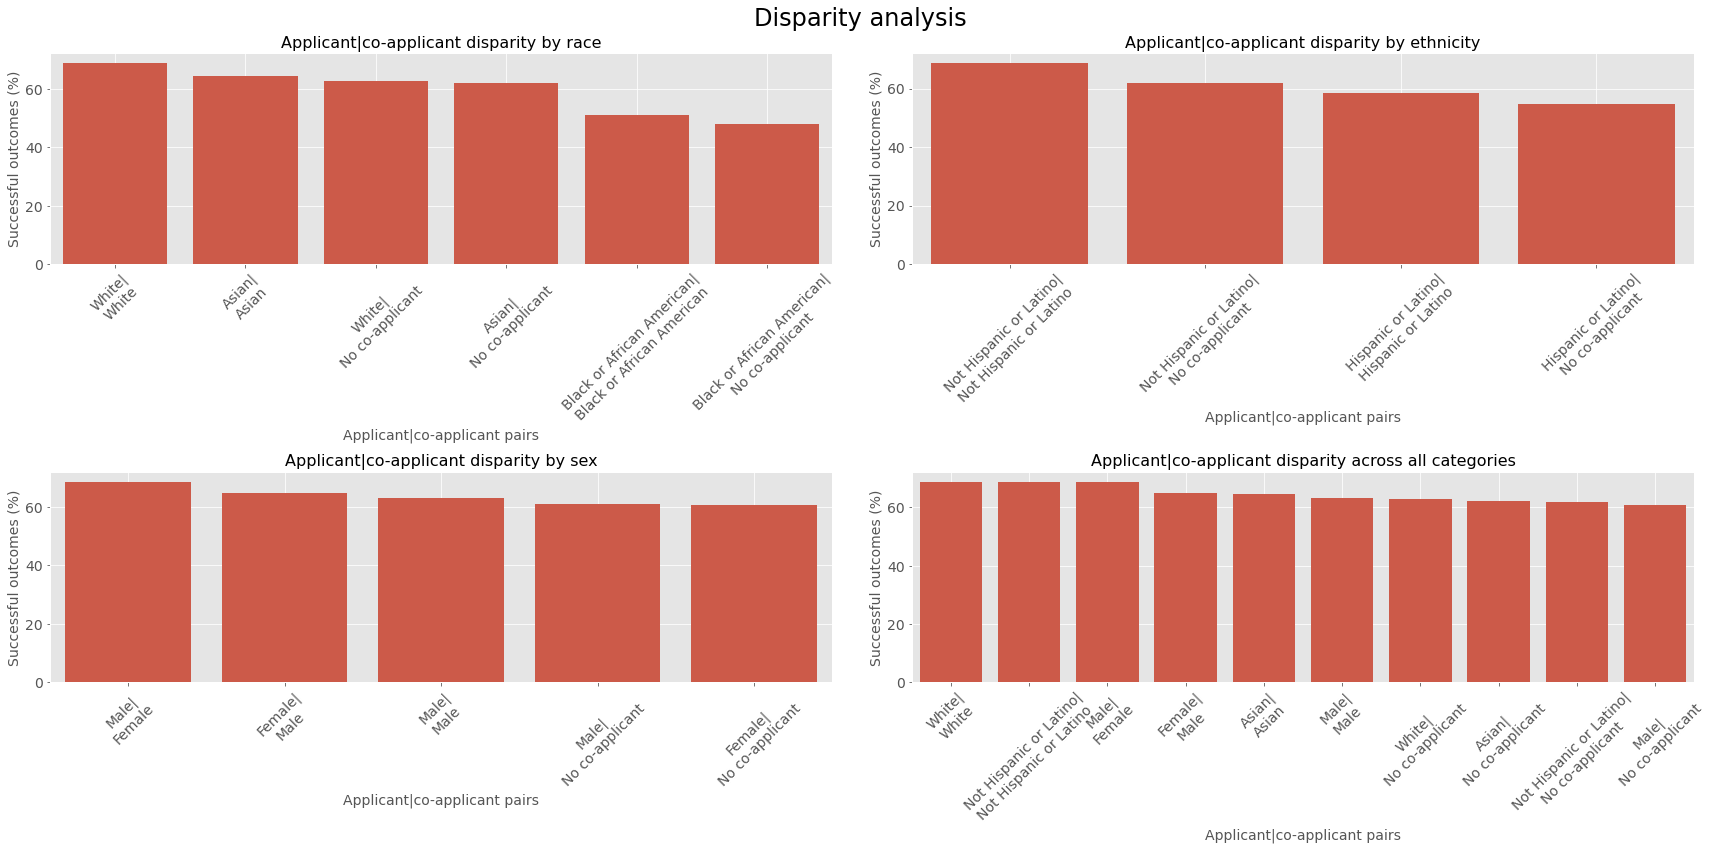

In [25]:
fig,axes=plt.subplots(2,2,figsize=(24,12))
plt.style.use('ggplot')

dff=df_stat_disp[['Characteristic','Applicant|Co-applicant','Successful (%)']]

#by race
z=dff[dff['Characteristic']=='applicant_race_name_1'].sort_values(by='Successful (%)',ascending=False).head(10)
sns.barplot(data=z,x='Applicant|Co-applicant',y='Successful (%)',ax=axes[0,0])
axes[0,0].set_ylabel('Successful outcomes (%)',fontsize=14)
axes[0,0].set_title('Applicant|co-applicant disparity by race',fontsize=16)

#by ethnicity
z=dff[dff['Characteristic']=='applicant_ethnicity_name'].sort_values(by='Successful (%)',ascending=False).head(10)
sns.barplot(data=z,x='Applicant|Co-applicant',y='Successful (%)',ax=axes[0,1])
axes[0,1].set_ylabel('Successful outcomes (%)',fontsize=14)
axes[0,1].set_title('Applicant|co-applicant disparity by ethnicity',fontsize=16)

#by sex
z=dff[dff['Characteristic']=='applicant_sex_name'].sort_values(by='Successful (%)',ascending=False).head(10)
sns.barplot(data=z,x='Applicant|Co-applicant',y='Successful (%)',ax=axes[1,0])
axes[1,0].set_ylabel('Successful outcomes (%)',fontsize=14)
axes[1,0].set_title('Applicant|co-applicant disparity by sex',fontsize=16)

#across all categories
z=dff.sort_values(by='Successful (%)',ascending=False).head(10)
sns.barplot(data=z,x='Applicant|Co-applicant',y='Successful (%)',ax=axes[1,1])
axes[1,1].set_ylabel('Successful outcomes (%)',fontsize=14)
axes[1,1].set_title('Applicant|co-applicant disparity across all categories',fontsize=16)


for i in range(2):
    for j in range(2):
        axes[i,j].tick_params(axis='x',labelsize=14,rotation=45)
        axes[i,j].tick_params(axis='y',labelsize=14)
        axes[i,j].set_xlabel('Applicant|co-applicant pairs',fontsize=14)
        axes[i,j].set_axisbelow(True)
        axes[i,j].grid(True)

fig.suptitle('Disparity analysis',fontsize=24)
plt.tight_layout()

#uncomment for saving
#plt.savefig("DISPARITY STATS (BARCHART).png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

del dff

### The disparity analysis shows visible differences in loan success rates across applicant/co-applicant race, ethnicity, and sex combinations.

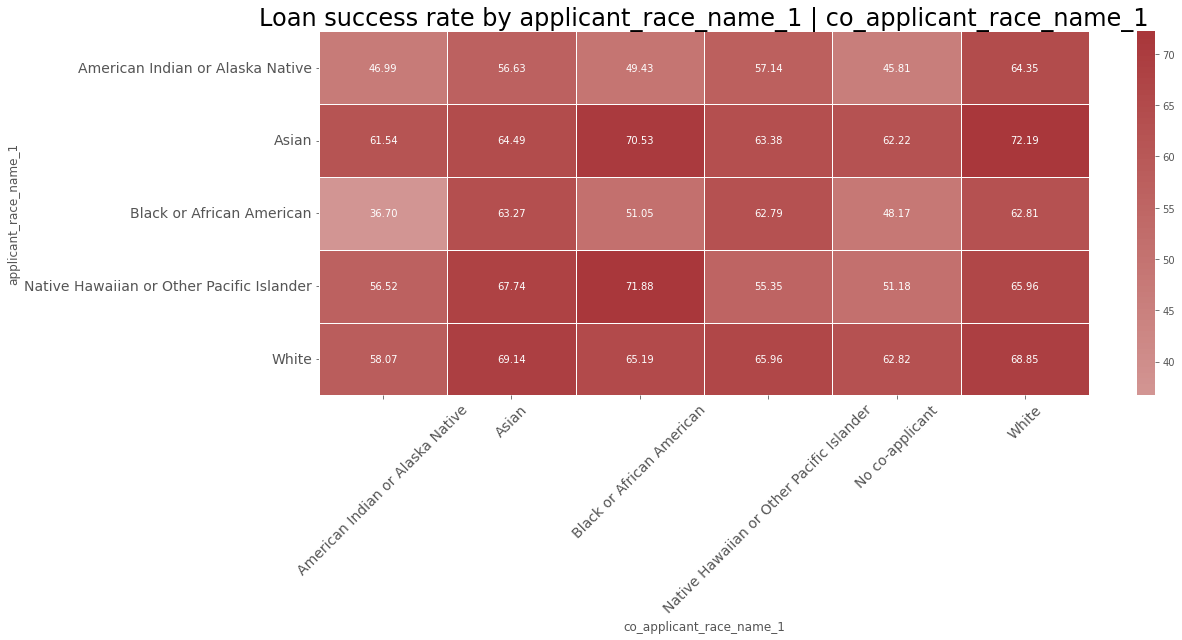

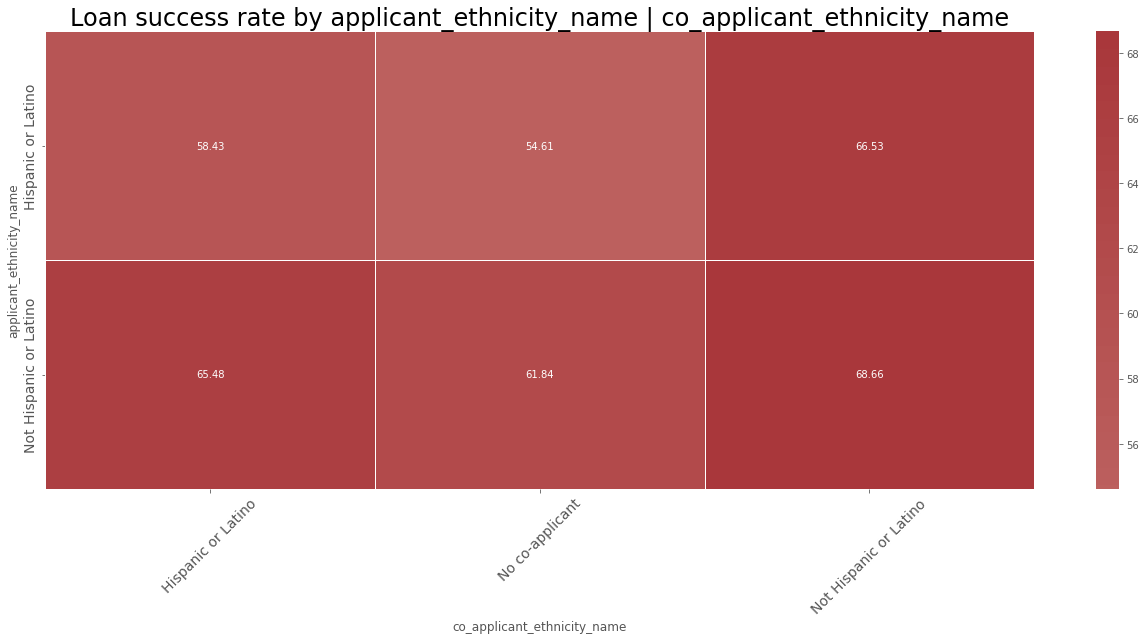

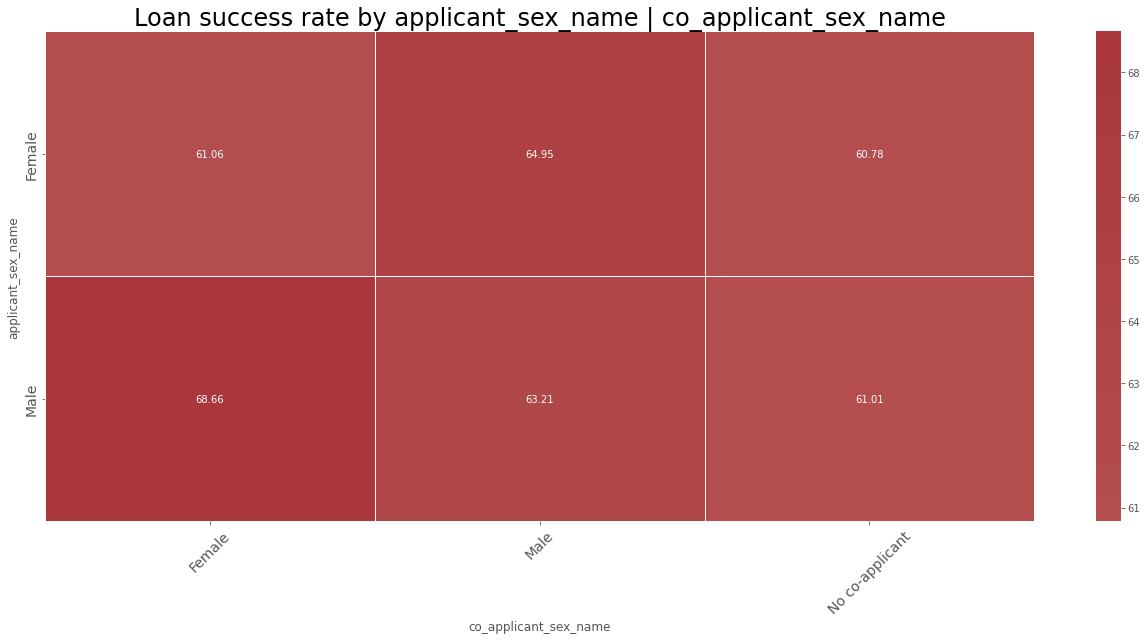

In [26]:
for applicant in ['applicant_race_name_1','applicant_ethnicity_name','applicant_sex_name']:

    pivot=(
        df.pivot_table(
            index=applicant,
            columns='co_'+applicant,
            values='loan_success',
            aggfunc='mean'
        )*100
    ).round(2)

    fig,axes=plt.subplots(1,1,figsize=(18,9))
    plt.style.use('ggplot')

    sns.heatmap(pivot,annot=True,cmap='vlag',center=0,linewidth=1,fmt=".2f",ax=axes)
    axes.set_title(f'Loan success rate by {applicant} | co_{applicant}',fontsize=24)

    axes.tick_params(axis='x',labelsize=14,rotation=45)
    axes.tick_params(axis='y',labelsize=14)
    axes.set_axisbelow(True)
    axes.grid(True)

    plt.tight_layout()

    #uncomment for saving
    #plt.savefig(f"PIVOTED DISPARITY HEATMAP W.R.T {applicant} .png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

    plt.show()

### Loan success rates differ across applicant and co-applicant demographic combinations. Some groups show noticeably lower origination rates, especially in the race-based heatmap. These results should be interpreted as descriptive disparities only, not as proof of discrimination, since other factors such as income, loan amount, geography, loan purpose, and property characteristics are not controlled for here.

### Feature selection via SelectKBest using Chi2

In [27]:
#data preparation
x=filtered_columns_cat.copy()
x.remove('action_taken_name')

y=filtered_columns_num.copy()
y.remove('state_code')
y.remove('county_code')
y.remove('census_tract_number')

feature_columns=x+y

X=df[feature_columns].copy()
Y=df['loan_success']

#preprocessor
num_pipe=Pipeline([
                    ('imputer',SimpleImputer(strategy='median')),
                    ('scaler',MinMaxScaler())
                  ])

cat_pipe=Pipeline([
                    ('imputer',SimpleImputer(strategy='most_frequent')),
                    ('onehot',OneHotEncoder(handle_unknown='ignore'))
                  ])

preprocessor=ColumnTransformer([
                                ('num',num_pipe,y),
                                ('cat',cat_pipe,x)
                               ])
#kbest
kbest_pipe=Pipeline([
                        ('preprocess', preprocessor),
                        ('kbest', SelectKBest(score_func=chi2,k='all'))
                    ])

kbest_pipe.fit(X,Y)

#save the results as a df
feature_names=kbest_pipe.named_steps['preprocess'].get_feature_names_out()

scores_list=kbest_pipe.named_steps['kbest'].scores_
p_values_list=kbest_pipe.named_steps['kbest'].pvalues_

df_kbest_results=pd.DataFrame({'Feature':feature_names,
                               'Score':scores_list,
                               'P-values':p_values_list
                              }).sort_values(by=['Score','P-values'],ascending=False)

del x,y

### Plot

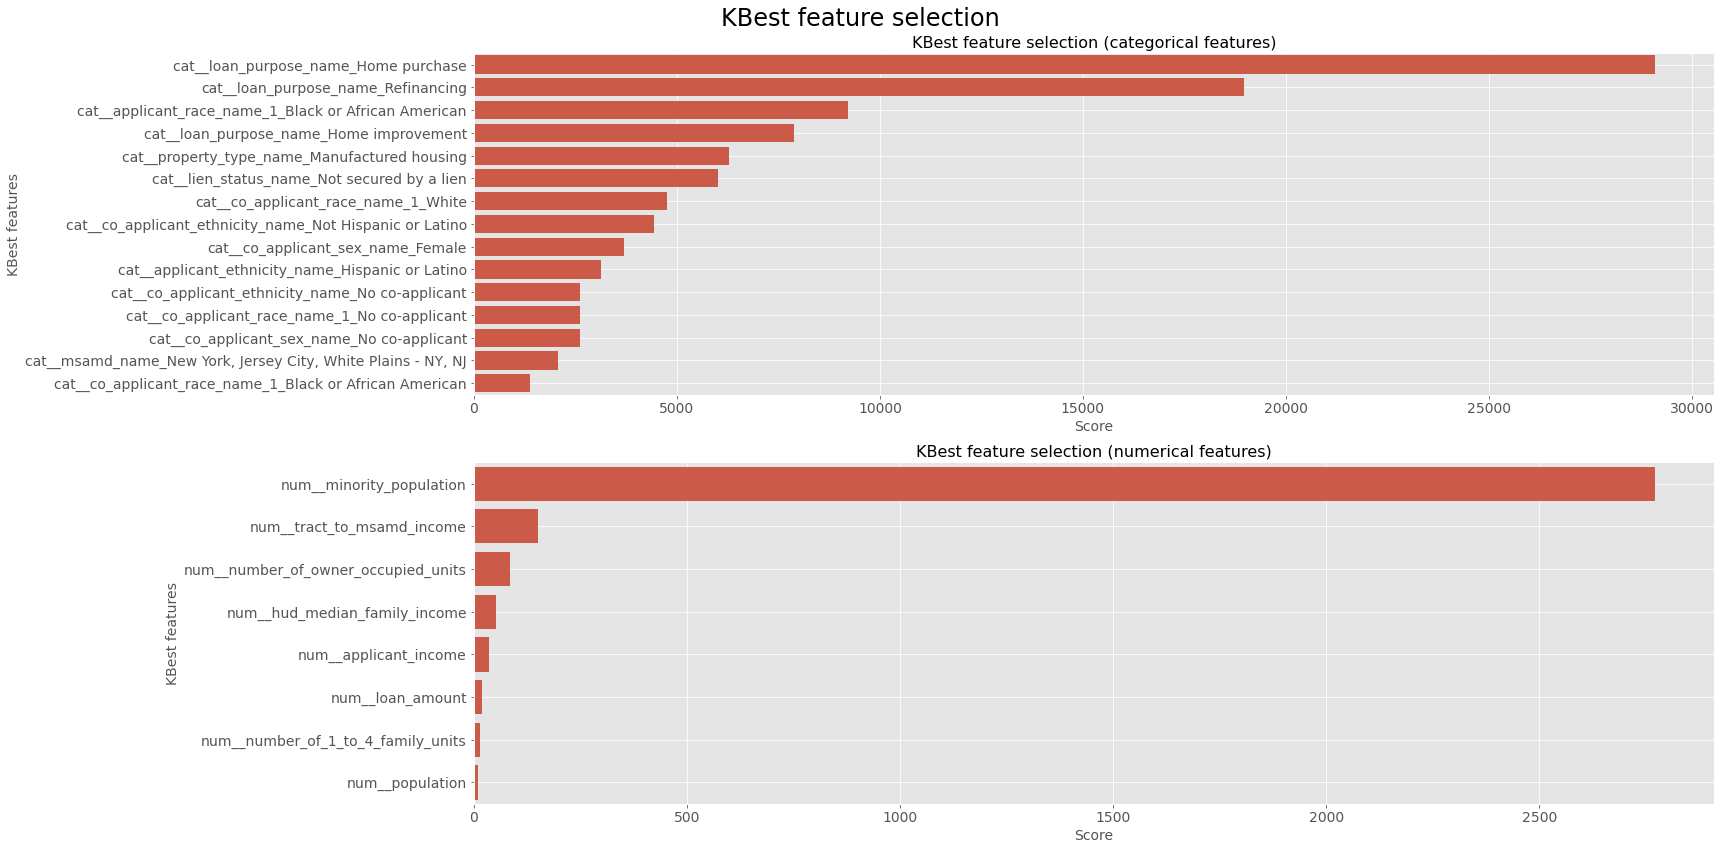

In [28]:
fig,axes=plt.subplots(2,1,figsize=(24,12))
plt.style.use('ggplot')

#categorical
z=(df_kbest_results[df_kbest_results['Feature']
                    .str.startswith('cat')]
                    .set_index('Feature')['Score']
                    .head(15))
sns.barplot(x=z.values,y=z.index,ax=axes[0])
axes[0].set_ylabel('KBest features',fontsize=14)
axes[0].set_title('KBest feature selection (categorical features)',fontsize=16)

#numerical
z=(df_kbest_results[df_kbest_results['Feature']
                    .str.startswith('num')]
                    .set_index('Feature')['Score']
                    .head(15))
sns.barplot(x=z.values,y=z.index,ax=axes[1])
axes[1].set_ylabel('KBest features',fontsize=14)
axes[1].set_title('KBest feature selection (numerical features)',fontsize=16)


for j in range(2):
    axes[j].tick_params(axis='x',labelsize=14)
    axes[j].tick_params(axis='y',labelsize=14)
    axes[j].set_xlabel('Score',fontsize=14)
    axes[j].set_axisbelow(True)
    axes[j].grid(True)

fig.suptitle('KBest feature selection',fontsize=24)
plt.tight_layout()

#uncomment for saving
#plt.savefig("KBEST FEATURE SELECTION.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### KBest feature selection suggests that loan purpose, applicant/co-applicant race, property type, lien status, and income-related variables are among the strongest predictors of loan success.

### Correlation analysis

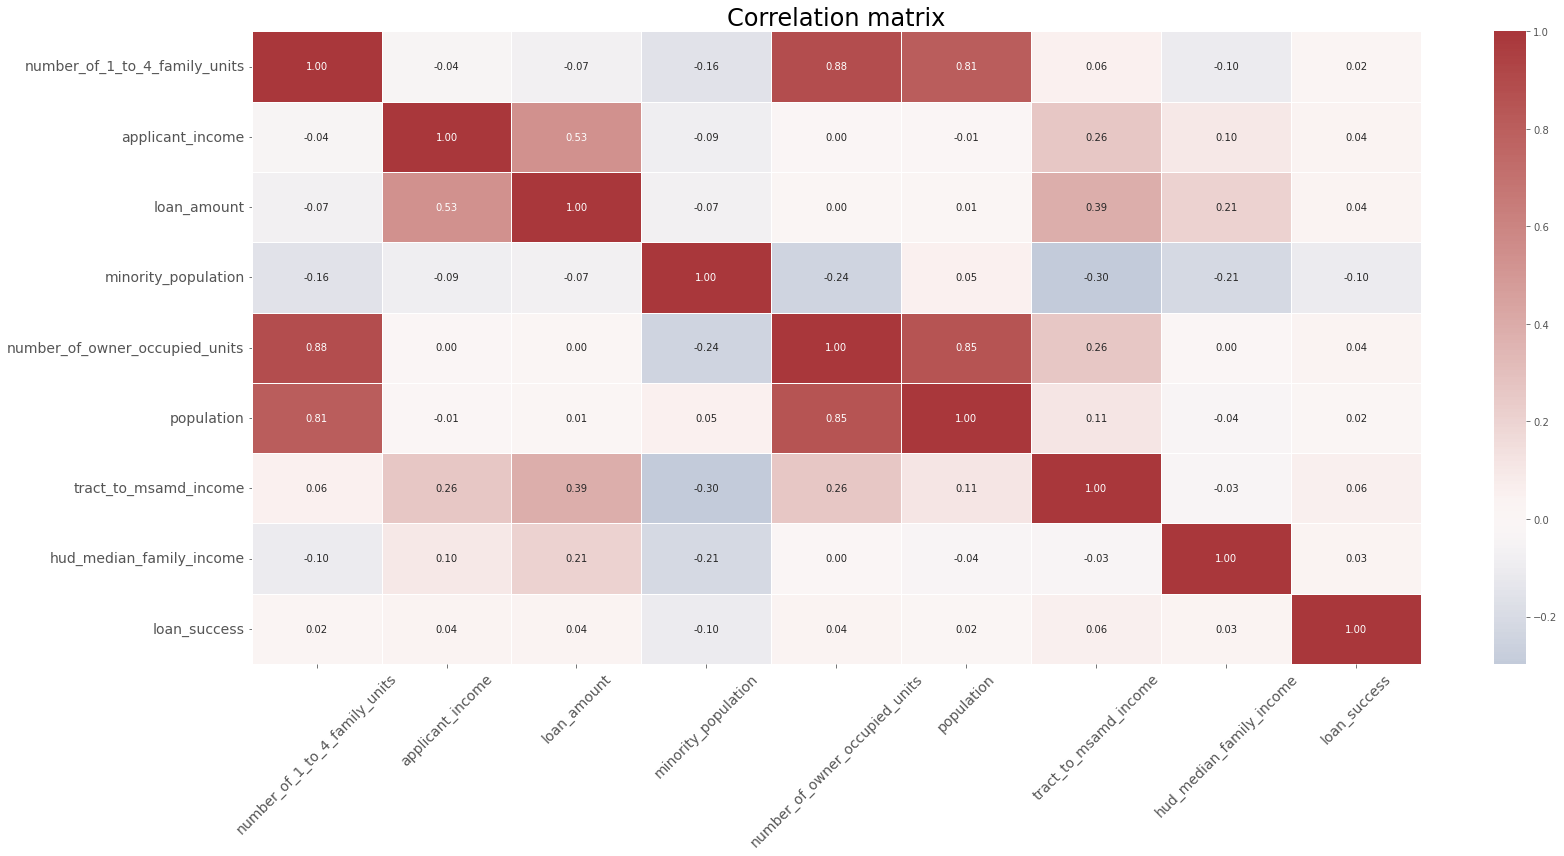

In [29]:
filtered_columns_num_corr=filtered_columns_num.copy()
filtered_columns_num_corr.append('loan_success')
filtered_columns_num_corr.remove('state_code')
filtered_columns_num_corr.remove('county_code')
filtered_columns_num_corr.remove('census_tract_number')

fig,axes=plt.subplots(1,1,figsize=(24,12))
plt.style.use('ggplot')

sns.heatmap(df[filtered_columns_num_corr].corr(),annot=True,cmap='vlag',center=0,linewidth=1,fmt=".2f",ax=axes)
axes.set_title('Correlation matrix',fontsize=24)

axes.tick_params(axis='x',labelsize=14,rotation=45)
axes.tick_params(axis='y',labelsize=14)
axes.set_axisbelow(True)
axes.grid(True)

plt.tight_layout()

#uncomment for saving
#plt.savefig("HEATMAP.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### The numeric correlation matrix shows strong relationships between population-related variables, especially population, owner-occupied units, and 1–4 family units. Loan amount is moderately correlated with applicant income, which is expected. Loan success has only weak linear correlations with the numeric variables, suggesting that categorical variables and non-linear relationships may be more important for prediction.

# ___ ___ ___

# Part 3

- classification, threshold tuning and baseline comparison
- confusion matrix & other visuals for the best performing models

# ___ ___ ___

### We will now proceed with machine learning and threshold tuning

In [30]:
# for the mined data that we import we have initially used the following sample:
#
# N_rows=2000000
# chunk_size=100000

# df0=pd.read_csv('hmda_2014_nationwide_all-records_labels.csv',usecols=filtered_columns,nrows=N_rows,chunksize=chunk_size)
# df=pd.concat(df0,ignore_index=True)

### Select the 3 best performing models (above the baseline)

### Plot confusion matrices and other visuals for those 3 models